<a href="https://colab.research.google.com/github/Trishti-s/Deep_Learning/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded=files.upload()

data=pd.read_csv(list(uploaded.keys())[0])
data.head()

Saving multiple_linear_regression_dataset (1).csv to multiple_linear_regression_dataset (1).csv


,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [3]:
X=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

X=(X-X.mean(axis=0))/X.std(axis=0)
print("Input shape",X.shape)


Input shape (20, 2)


In [4]:
class PerceptronRegression:

    def __init__(self, lr=0.01, epochs=1000):
        self.lr=lr
        self.epochs=epochs

    def fit(self, X, y):
        n_samples,n_features=X.shape

        self.weights=np.zeros(n_features)
        self.bias=0

        for _ in range(self.epochs):

            y_pred=np.dot(X, self.weights)+self.bias

            dw=(-2/n_samples) * np.dot(X.T, (y - y_pred))
            db=(-2/n_samples) * np.sum(y - y_pred)


            self.weights-=self.lr * dw
            self.bias-=self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights)+self.bias

In [5]:
model=PerceptronRegression(lr=0.01,epochs=1000)
model.fit(X, y)

print("Weights:",model.weights)
print("Bias:",model.bias)

Weights: [-967.38673178 8690.62674248]
Bias: 40735.49993144349


In [6]:
predictions=model.predict(X)

print("First 10 Predictions:")
print(predictions[:10])

First 10 Predictions:
[30943.77257831 34772.63412357 30928.1445882  38898.42778617
 48619.04770799 41341.60611716 39294.33727597 36637.57620997
 38403.54092393 44691.20879029]


In [7]:
mse=np.mean((y - predictions)**2)
print("Mean Squared Error:", mse)

Mean Squared Error: 1533637.4723532568


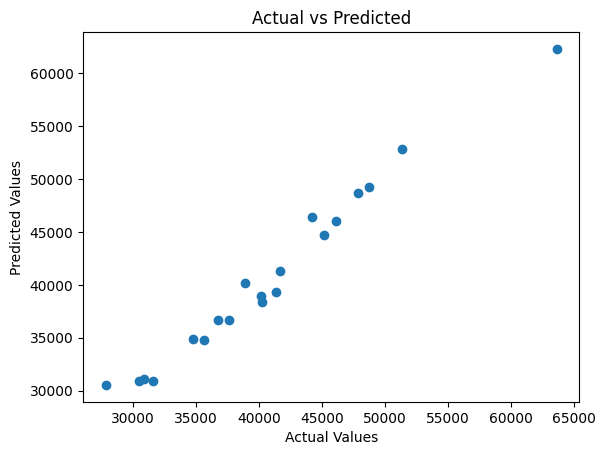

In [8]:
plt.scatter(y, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()